In [16]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../data/silver/cleaned_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits
0,5.0,9.270180,0.230652,Organic,3.890460,3
1,4.0,3.429316,0.391001,Social,8.478174,0
2,4.0,1.621052,0.397986,Organic,9.636170,2
3,5.0,3.629279,0.180458,Organic,2.071925,3
4,5.0,4.235843,0.291541,Paid,1.960654,5


In [18]:
df.describe()

,Page Views,Session Duration,Bounce Rate,Time on Page,Previous Visits
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.940250,2.864909,0.284446,3.947783,1.970000
std,2.153572,2.609911,0.158804,2.622799,1.403954
min,0.000000,0.003613,0.007868,0.068515,0.000000
25%,3.000000,0.815828,0.161986,1.935037,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000
max,10.500000,9.270180,0.728398,10.634011,6.000000


In [20]:
#Average time spend on per page by user 
df["Avg Time Per Page"] = df["Time on Page"] / df["Page Views"]

In [21]:
# Step 2: Return target using last 1 month previous visits and drop Previous vists column due to data leakage 
df["Return"] = (df["Previous Visits"] > 1).astype(int)
df = df.drop(columns=["Previous Visits"])

In [22]:
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Avg Time Per Page,Return
0,5.0,9.270180,0.230652,Organic,3.890460,0.778092,1
1,4.0,3.429316,0.391001,Social,8.478174,2.119544,0
2,4.0,1.621052,0.397986,Organic,9.636170,2.409042,1
3,5.0,3.629279,0.180458,Organic,2.071925,0.414385,1
4,5.0,4.235843,0.291541,Paid,1.960654,0.392131,1


In [23]:
percentages = df['Return'].value_counts(normalize=True) * 100
print(percentages)

Return
1    58.95
0    41.05
Name: proportion, dtype: float64


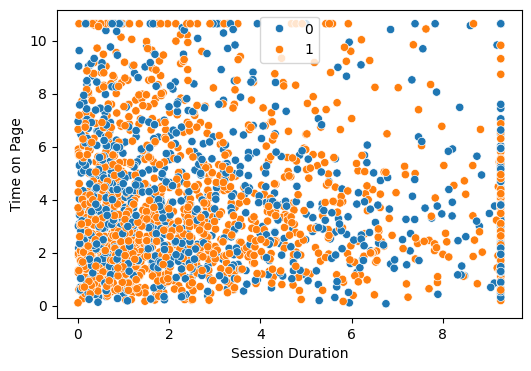

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Session Duration',y='Time on Page',hue= 'Return', data= df)
plt.legend()
plt.show()

In [25]:
#gold data stores parquet format in gold layer---because parquet format fast , take less size and big data frindly  

#pip install pyarrow---needded environment
 
#df.to_parquet("data/gold/feature_data.parquet", index=False)

In [24]:
df.to_csv("../data/gold/feature_data.csv", index=False)